# Customer Segmentation using Machine Learning

## Business objective
My project is **Customer Segmentation using Machine Learning**, based on a Marketing Campaign dataset containing 2,240 customer records and 29 columns.

The main objective is to group customers based on their demographic characteristics, product spending, purchasing behaviour, and marketing campaign responses. I performed data cleaning, exploratory data analysis, feature engineering, categorical encoding, and feature standardization before building the clustering models.

I implemented and evaluated two unsupervised machine learning algorithms: K-Means and DBSCAN. I used the Silhouette Score to evaluate clustering quality and compare the models. K-Means achieved a score of 0.2519, while DBSCAN achieved 0.3182. Based on the notebook's recorded results, DBSCAN was selected as the final model, identifying four clusters and classifying 120 customers as noise.

The project's business objective is to help companies understand different customer groups, create targeted marketing strategies, and improve customer engagement and promotional decisions.

## 1. Import Required Libraries

Only libraries required for data handling, visualization, preprocessing, clustering, evaluation, PCA, and model saving are imported.

In [37]:
import warnings
warnings.filterwarnings("ignore")
# Controls warning messages displayed in Python.

import numpy as np
# Performs mathematical operations and works with numerical arrays

import pandas as pd
# Loads, cleans, organizes, and analyzes tabular data.
    
import matplotlib.pyplot as plt
# Creates graphs and charts.

import seaborn as sns
# Creates statistical graphs using Matplotlib.

import joblib
# Saves Python objects to files and loads them later.

# Scikit-learn libraries
## Scikit-learn is the main machine learning library used in your project.

from sklearn.compose import ColumnTransformer
# Applies different preprocessing operations to different columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
# StandardScaler
## Standardizes numerical features so they generally have a mean of 0 and a standard deviation of 1.

# OneHotEncoder
## Converts categorical values into binary columns.

from sklearn.impute import SimpleImputer
# Replaces missing values.
## Numerical columns: fill missing values using the median.
## Categorical columns: fill missing values using the most frequent category

from sklearn.pipeline import Pipeline
# Combines several operations into one sequential workflow.
## Instead of separately imputing and scaling numerical features, you can combine both operations.

from sklearn.cluster import KMeans, DBSCAN
# KMeans : Groups customers into a predefined number of clusters.
# DBSCAN : Groups points based on the density of nearby observations

from sklearn.metrics import silhouette_score
# Measures how well-separated and cohesive the clusters are.

from sklearn.neighbors import NearestNeighbors
# Finds the nearest observations to each data point.

from sklearn.decomposition import PCA
# Reduces the number of dimensions in a dataset while retaining as much variance as possible in the selected components.

## 2. Load the Dataset

In [38]:
# Read the Excel file
data1 = pd.ExcelFile("marketing_campaign.xlsx")
data1

In [39]:
# Display Excel sheet names
data1.sheet_names

['marketing_campaign']

In [40]:
# Display the Tabular data
data = pd.read_excel("marketing_campaign.xlsx", sheet_name='marketing_campaign')
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


## 3. Initial data understanding
Check structure, data types, summary statistics, missing values, and duplicate records before cleaning.

In [41]:
print("Shape:", data.shape)

Shape: (2240, 29)


In [42]:
print("\nColumn names:", data.columns)


Column names: Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


In [43]:
print("Data types and non-null counts:", data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [44]:
# Display the details of all the columns
data.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ID,2240.0,NaN,NaN,NaN,5592.159821,0.0,2828.25,5458.5,8427.75,11191.0,3246.662198
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,1893.0,1959.0,1970.0,1977.0,1996.0,11.984069
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,1730.0,35303.0,51381.5,68522.0,666666.0,25173.076661
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.0,0.0,0.0,1.0,2.0,0.544538
Dt_Customer,2240,NaN,NaN,NaN,2013-07-10 10:01:42.857142784,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 12:00:00,2013-12-30 06:00:00,2014-06-29 00:00:00,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,0.0,24.0,49.0,74.0,99.0,28.962453
MntWines,2240.0,NaN,NaN,NaN,303.935714,0.0,23.75,173.5,504.25,1493.0,336.597393


In [45]:
# Display Null values
missing_values = data.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Income    24
dtype: int64

In [46]:
# Replacing null values with mean
data['Income'] = data['Income'].fillna(data['Income'].mean())

## 4. Data Quality Checks

Duplicate customers can distort clustering because repeated records give the same customer type extra weight. We check both complete duplicate rows and duplicate customer IDs.

In [47]:
print("Duplicate rows:", data.duplicated().sum())
print("Duplicate customer IDs:", data["ID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


## 5. Feature Engineering

Raw columns are combined into business-oriented customer measures. These features are easier to interpret than using every raw column independently.

- **Age**: approximate customer age based on the dataset year.
- **Total_Children**: children + teenagers at home.
- **Total_Spending**: total amount spent across product categories.
- **Total_Purchases**: purchases across web, catalog, and store channels.
- **Total_Campaign_Acceptance**: number of accepted campaigns.

In [48]:
# These columns represent the amount of money each customer spent on different product categories during the last two years.
spending_columns = [
    "MntWines",           # Money spent on wine
    "MntFruits",          # Money spent on fruits
    "MntMeatProducts",    # Money spent on meat products
    "MntFishProducts",    # Money spent on fish products
    "MntSweetProducts",   # Money spent on sweet products
    "MntGoldProds"        # Money spent on gold products
]

# These columns represent the number of purchases made through different ways.
purchase_columns = [
    "NumWebPurchases",     # Purchases made through the website
    "NumCatalogPurchases", # Purchases made using a catalogue
    "NumStorePurchases"    # Purchases made directly in stores
]

# These columns indicate whether customers accepted offers from five previous marketing campaigns and the latest campaign.
campaign_columns = [
    "AcceptedCmp1", # Accepted the offer in campaign 1
    "AcceptedCmp2", # Accepted the offer in campaign 2
    "AcceptedCmp3", # Accepted the offer in campaign 3
    "AcceptedCmp4", # Accepted the offer in campaign 4
    "AcceptedCmp5", # Accepted the offer in campaign 5
    "Response"      # Accepted the offer in the latest campaign
]

data["Age"] = 2026 - data["Year_Birth"]
data["Total_Children"] = data["Kidhome"] + data["Teenhome"]
data["Total_Spending"] = data[spending_columns].sum(axis=1)
data["Total_Purchases"] = data[purchase_columns].sum(axis=1)
data["Total_Campaign_Acceptance"] = data[campaign_columns].sum(axis=1)

data[[
    "Age",
    "Total_Children",
    "Total_Spending",
    "Total_Purchases",
    "Total_Campaign_Acceptance"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2240.0,57.194196,11.984069,30.0,49.00,56.0,67.0,133.0
Total_Children,2240.0,0.950446,0.751803,0.0,0.00,1.0,1.0,3.0
Total_Spending,2240.0,605.798214,602.249288,5.0,68.75,396.0,1045.5,2525.0
Total_Purchases,2240.0,12.537054,7.205741,0.0,6.00,12.0,18.0,32.0
Total_Campaign_Acceptance,2240.0,0.446875,0.890543,0.0,0.00,0.0,1.0,5.0


## 6. Handle Extreme Values for Clustering

Customer spending and income are naturally right-skewed. Instead of repeatedly deleting rows using sequential IQR filters, we retain customers and cap extreme numeric values at the 1st and 99th percentiles. This reduces the influence of extreme observations while preserving the customer population.

### Check suspicious values

The dataset contains a few known quality issues:

- `Income = 666666` is an extreme value that is treated as invalid.
- Very old `Year_Birth` values are treated as implausible for this customer dataset.

Instead of deleting customers immediately, these values are converted to missing values and handled later using median imputation.

In [49]:
print("Income summary:")
print(data["Income"].describe())

Income summary:
count      2240.000000
mean      52247.251354
std       25037.797168
min        1730.000000
25%       35538.750000
50%       51741.500000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64


In [50]:
print("\nYear of birth summary:")
print(data["Year_Birth"].describe())


Year of birth summary:
count    2240.000000
mean     1968.805804
std        11.984069
min      1893.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, dtype: float64


In [51]:
numeric_columns = data.select_dtypes(include="number").columns.tolist()

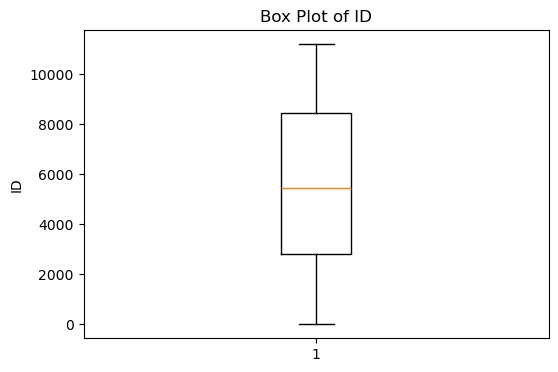

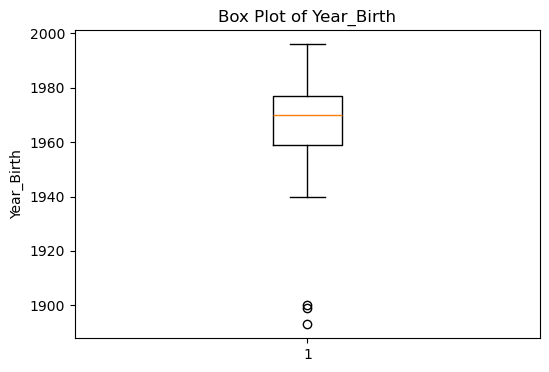

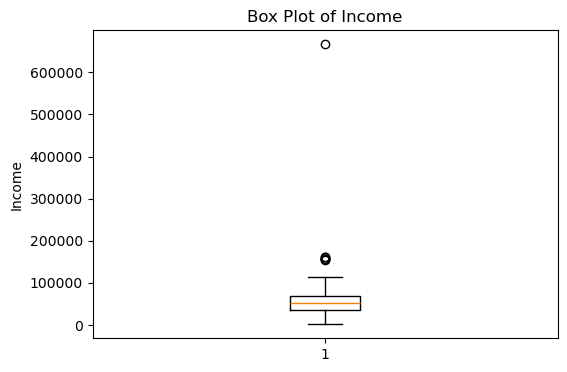

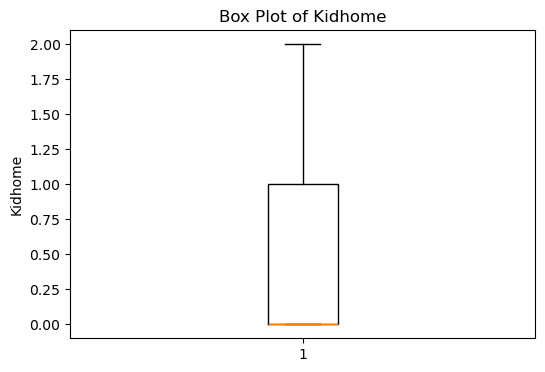

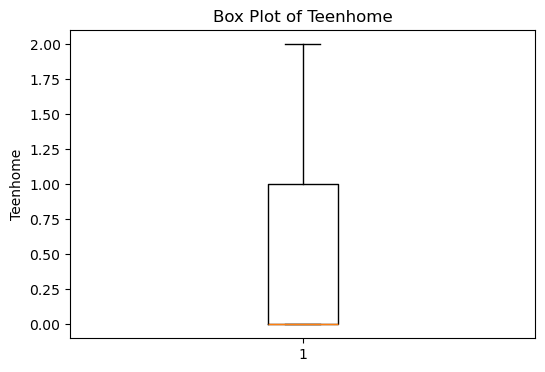

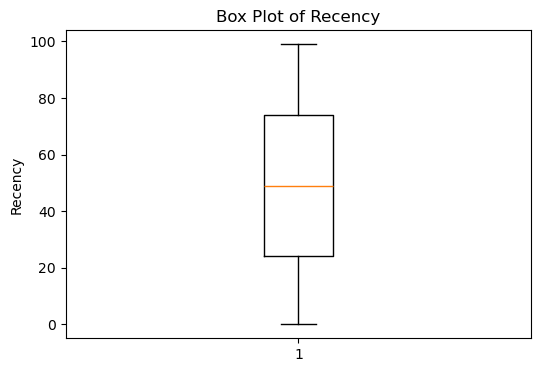

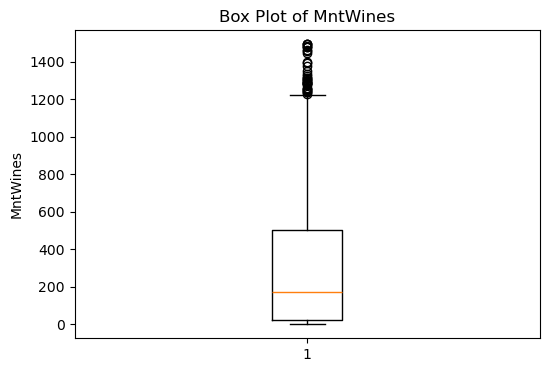

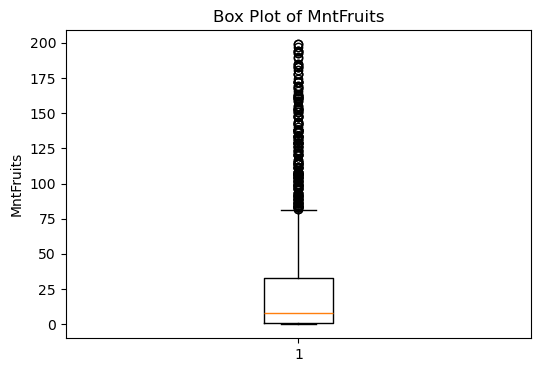

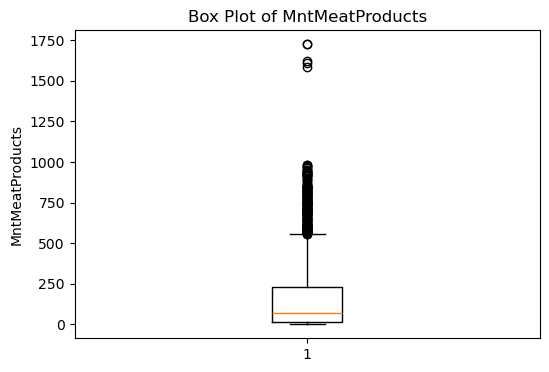

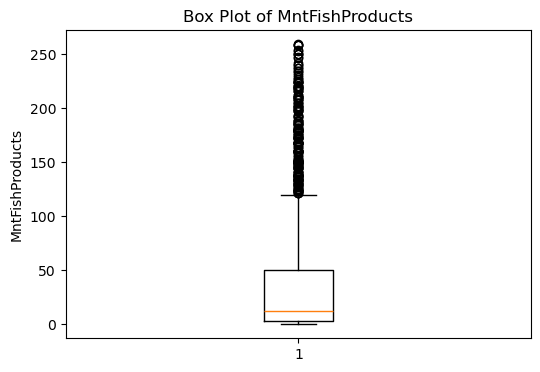

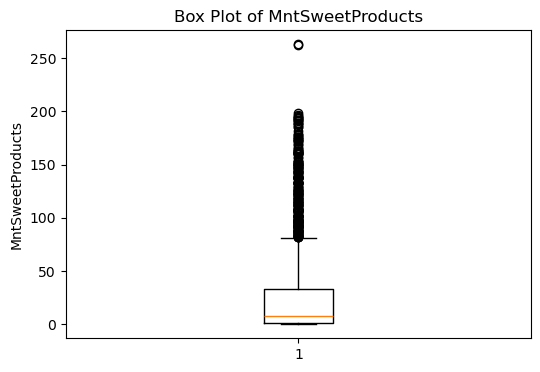

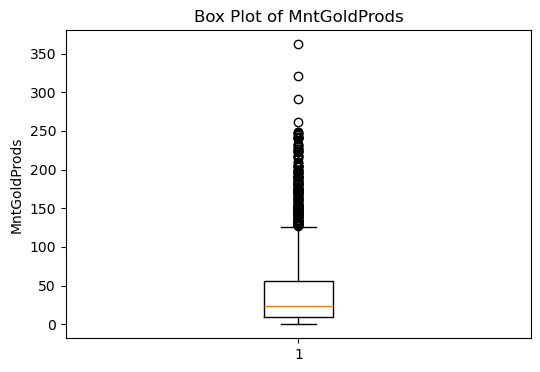

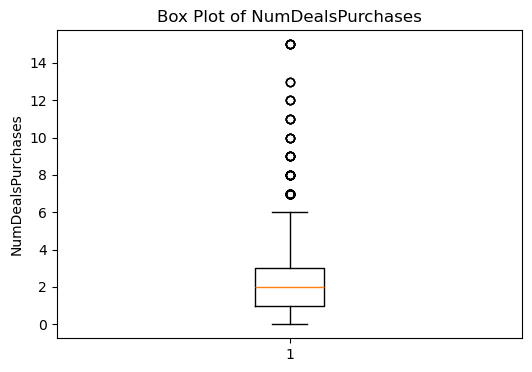

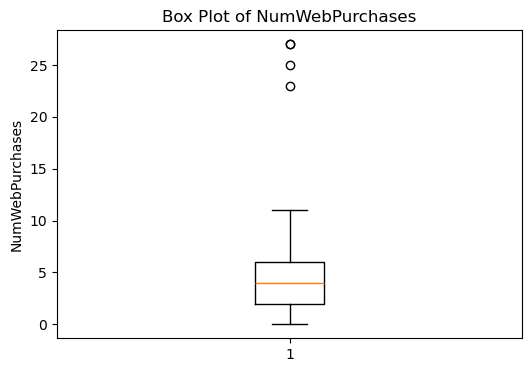

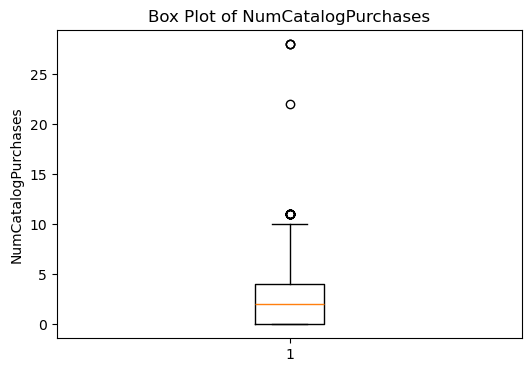

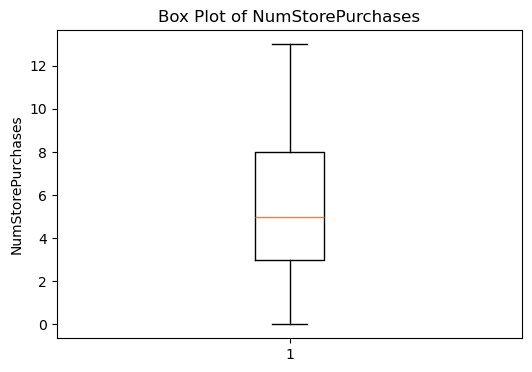

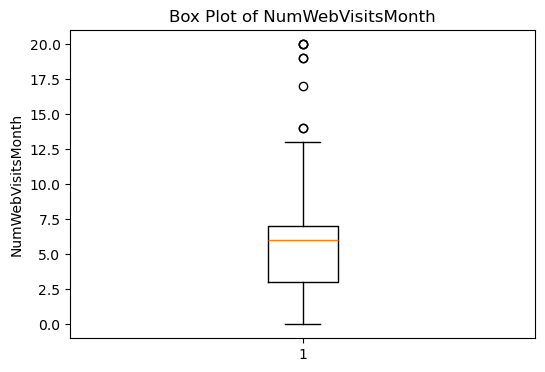

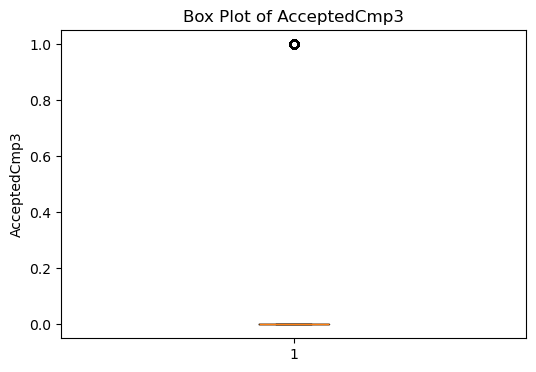

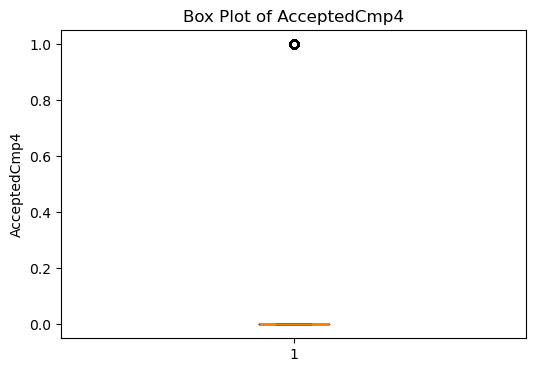

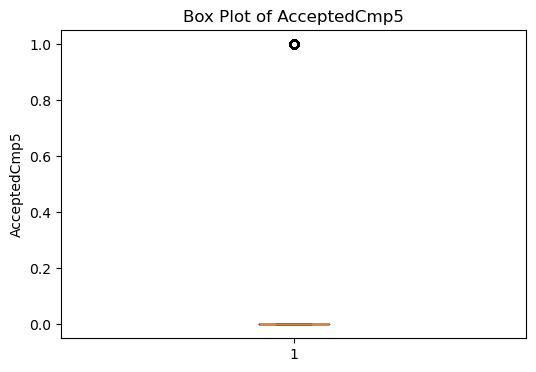

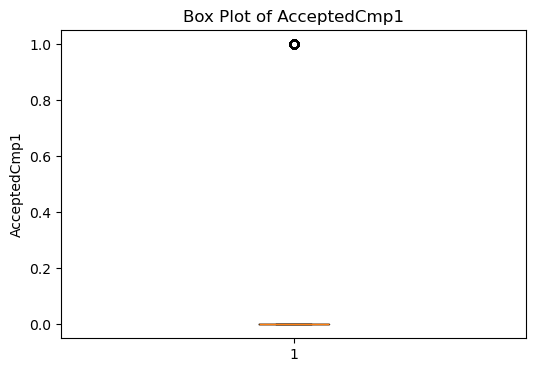

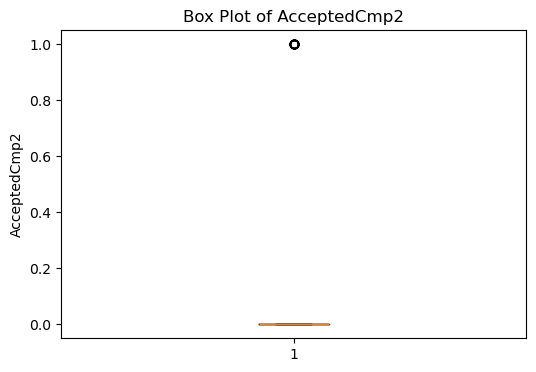

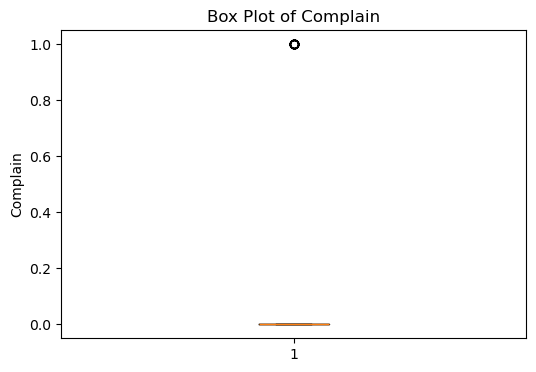

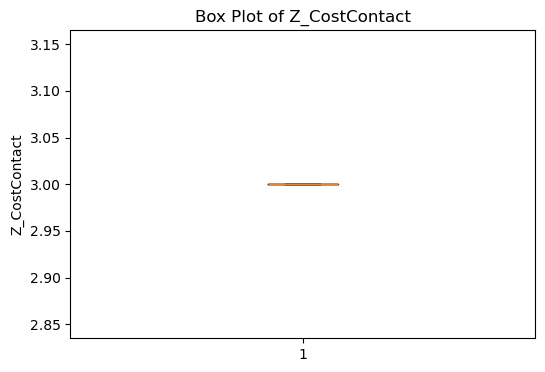

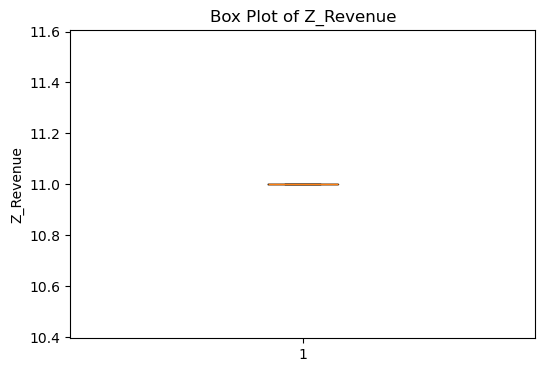

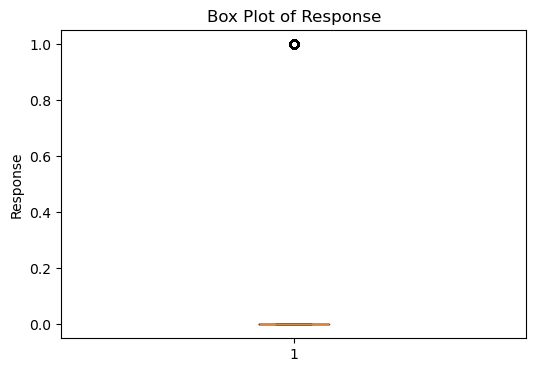

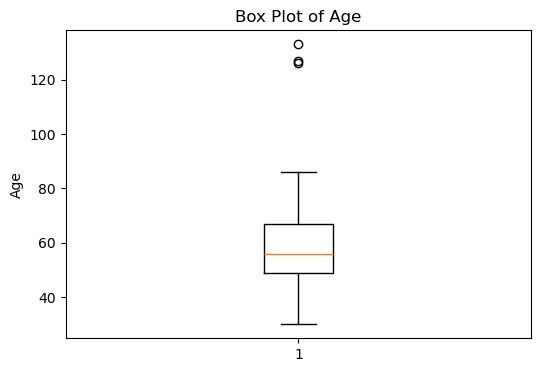

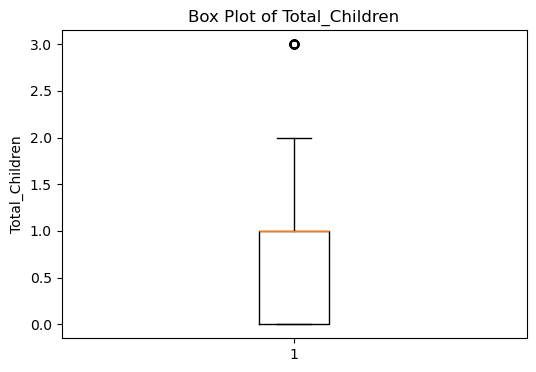

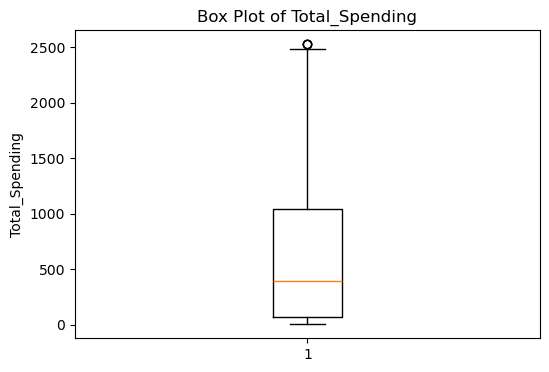

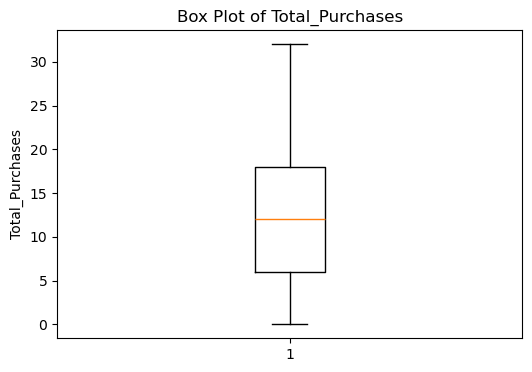

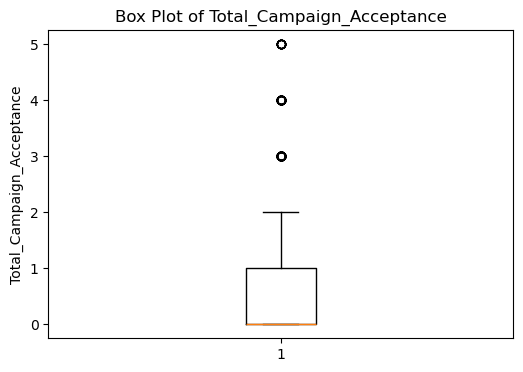

In [52]:
for column in numeric_columns:
    plt.figure(figsize=(6, 4))

    plt.boxplot(data[column].dropna())

    plt.title(f"Box Plot of {column}")
    plt.ylabel(column)

    plt.show()

In [60]:

# Create a copy of the original dataset
data_clean = data.copy()

for column in numeric_columns:

    Q1 = data_clean[column].quantile(0.25)
    Q3 = data_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Remove outliers from the current cleaned dataset
    data_clean = data_clean[
        (data_clean[column] >= lower_limit) &
        (data_clean[column] <= upper_limit)
    ]

# Compare the results
print("Original shape:", data.shape)
print("Cleaned shape:", data_clean.shape)
print("Rows removed:", len(data) - len(data_clean))

data_clean.describe()

Original shape: (2240, 34)
Cleaned shape: (765, 34)
Rows removed: 1475


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Total_Purchases,Total_Campaign_Acceptance
count,765.000000,765.000000,765.000000,765.000000,765.000000,765,765.000000,765.000000,765.000000,765.000000,...,765.0,765.0,765.0,765.0,765.0,765.000000,765.000000,765.000000,765.000000,765.0
mean,5674.670588,1971.499346,33742.533026,0.809150,0.465359,2013-08-27 06:37:10.588235264,51.027451,28.219608,3.942484,16.729412,...,0.0,0.0,3.0,11.0,0.0,54.500654,1.274510,69.250980,5.257516,0.0
min,9.000000,1940.000000,7500.000000,0.000000,0.000000,2012-08-01 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,3.0,11.0,0.0,31.000000,0.000000,8.000000,3.000000,0.0
25%,2836.000000,1965.000000,25271.000000,1.000000,0.000000,2013-03-18 00:00:00,26.000000,7.000000,0.000000,7.000000,...,0.0,0.0,3.0,11.0,0.0,47.000000,1.000000,34.000000,4.000000,0.0
50%,5527.000000,1972.000000,33562.000000,1.000000,0.000000,2013-09-11 00:00:00,51.000000,18.000000,2.000000,12.000000,...,0.0,0.0,3.0,11.0,0.0,54.000000,1.000000,55.000000,5.000000,0.0
75%,8420.000000,1979.000000,41713.000000,1.000000,1.000000,2014-02-16 00:00:00,77.000000,37.000000,5.000000,21.000000,...,0.0,0.0,3.0,11.0,0.0,61.000000,2.000000,91.000000,6.000000,0.0
max,11191.000000,1995.000000,64587.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,171.000000,47.000000,129.000000,...,0.0,0.0,3.0,11.0,0.0,86.000000,3.000000,223.000000,9.000000,0.0
std,3238.876197,10.856829,11493.219100,0.496237,0.527183,NaN,28.674797,30.849218,5.876062,15.005627,...,0.0,0.0,0.0,0.0,0.0,10.856829,0.705581,49.074041,1.589506,0.0


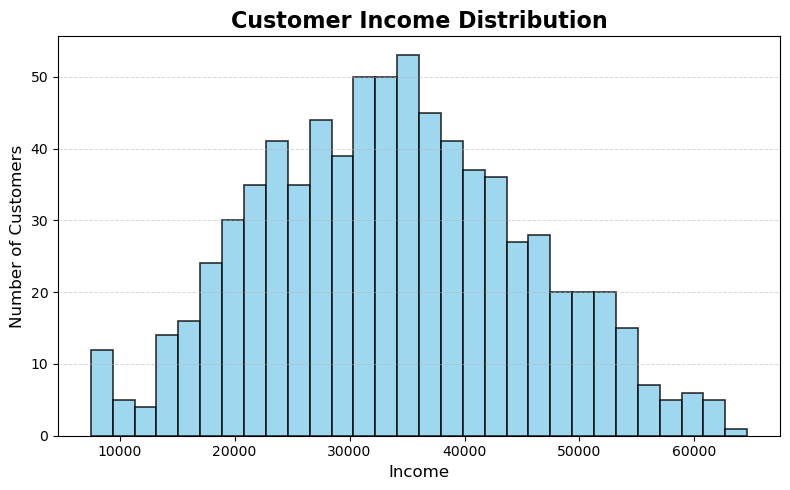

In [63]:
plt.figure(figsize=(8, 5))

plt.hist(
    data_clean["Income"],
    bins=30,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.8
)

plt.title("Customer Income Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Income", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

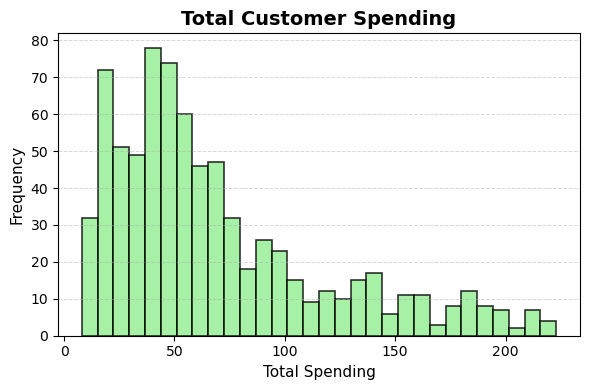

In [64]:
plt.figure(figsize=(6, 4))

plt.hist(
    data_clean["Total_Spending"],
    bins=30,
    color="lightgreen",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.8
)

plt.title("Total Customer Spending", fontsize=14, fontweight="bold")
plt.xlabel("Total Spending", fontsize=11)
plt.ylabel("Frequency", fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

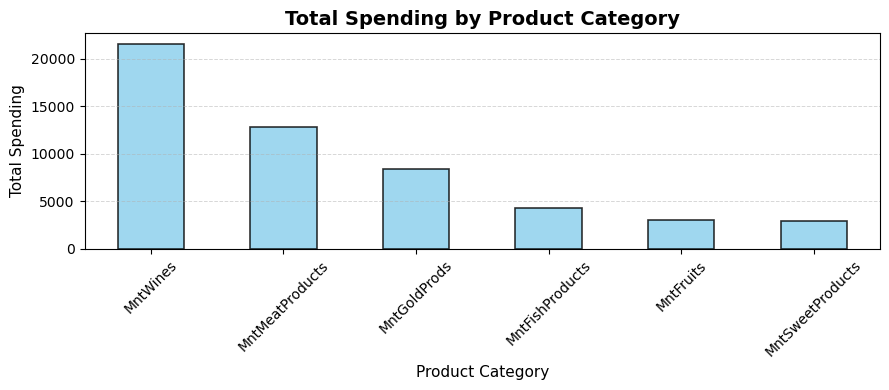

In [65]:
plt.figure(figsize=(9, 4))

data_clean[spending_columns].sum().sort_values(ascending=False).plot(
    kind="bar",
    color="skyblue",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.8
)

plt.title(
    "Total Spending by Product Category",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Product Category", fontsize=11)
plt.ylabel("Total Spending", fontsize=11)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

plt.tight_layout()
plt.show()

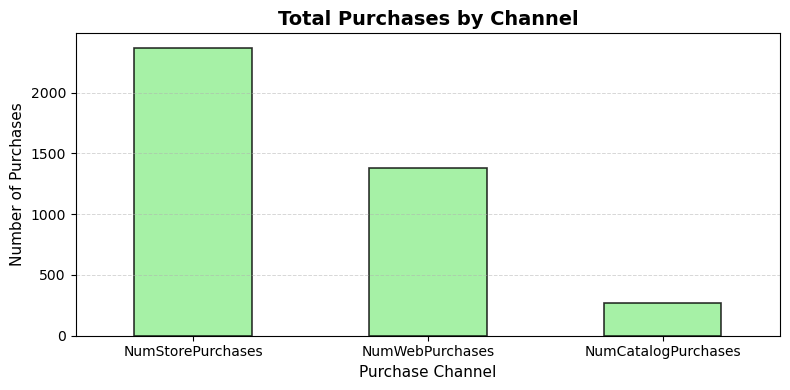

In [66]:
plt.figure(figsize=(8, 4))

data_clean[purchase_columns].sum().sort_values(ascending=False).plot(
    kind="bar",
    color="lightgreen",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.8
)

plt.title(
    "Total Purchases by Channel",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Purchase Channel", fontsize=11)
plt.ylabel("Number of Purchases", fontsize=11)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

plt.tight_layout()
plt.show()

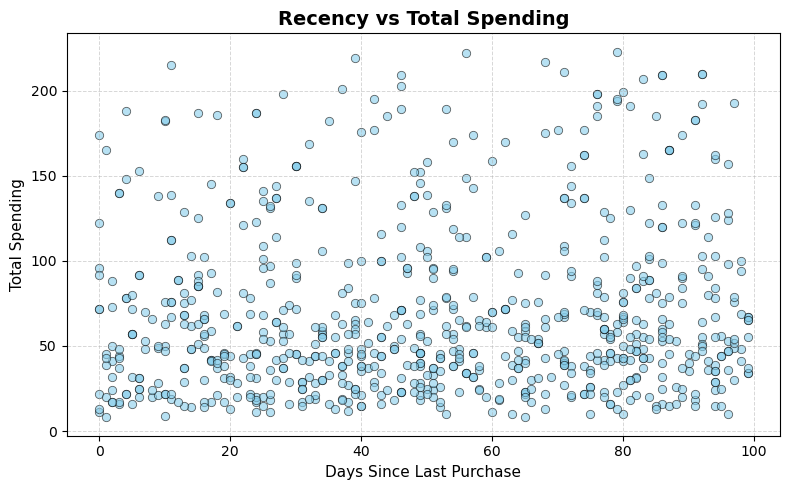

In [67]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data_clean["Recency"],
    data_clean["Total_Spending"],
    color="skyblue",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.6
)

plt.title(
    "Recency vs Total Spending",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Days Since Last Purchase", fontsize=11)
plt.ylabel("Total Spending", fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

plt.tight_layout()
plt.show()

# Categorical columns

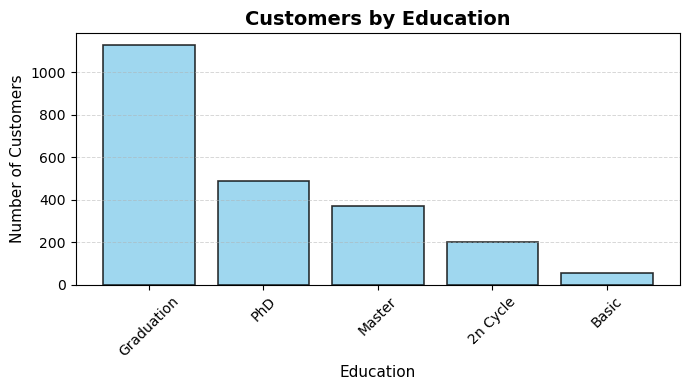

In [68]:
import matplotlib.pyplot as plt

education_counts = data["Education"].value_counts()

plt.figure(figsize=(7, 4))

plt.bar(
    education_counts.index,
    education_counts.values,
    color="skyblue",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.8
)

plt.title(
    "Customers by Education",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Education", fontsize=11)
plt.ylabel("Number of Customers", fontsize=11)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

plt.tight_layout()
plt.show()

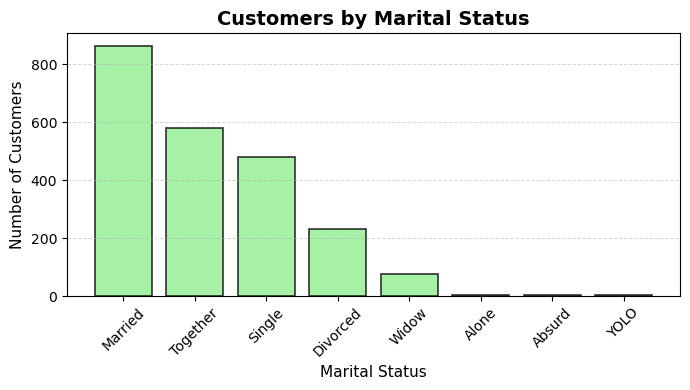

In [69]:
marital_counts = data["Marital_Status"].value_counts()

plt.figure(figsize=(7, 4))

plt.bar(
    marital_counts.index,
    marital_counts.values,
    color="lightgreen",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.8
)

plt.title(
    "Customers by Marital Status",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Marital Status", fontsize=11)
plt.ylabel("Number of Customers", fontsize=11)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

plt.tight_layout()
plt.show()

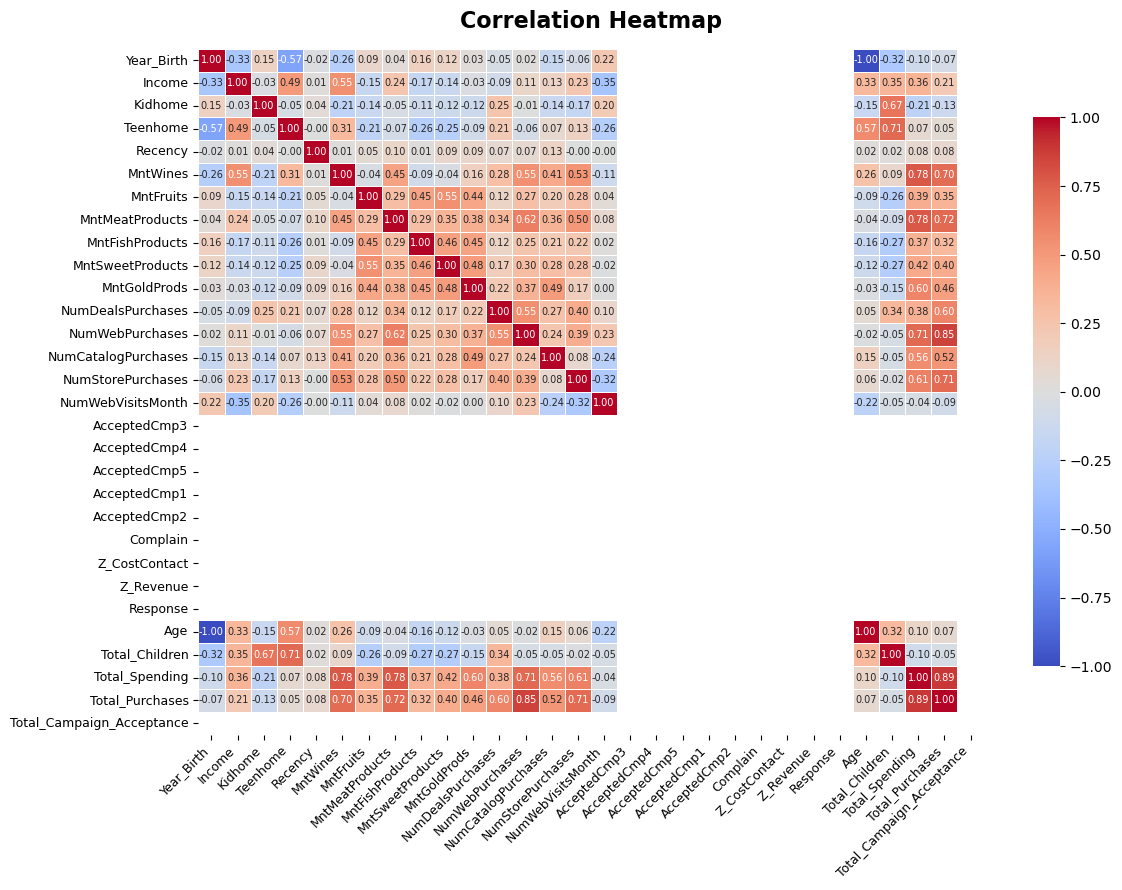

In [70]:
corr = data_clean[numeric_columns].drop(
    columns=["ID"],
    errors="ignore"
).corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

## Label Encoding

In [71]:
from sklearn.preprocessing import LabelEncoder

In [72]:
X = data_clean.drop('ID', axis=1)

In [73]:
label_enc = LabelEncoder()

In [74]:
labeled_data1 = label_enc.fit_transform(X['Education'])

In [75]:
X['Education'] = labeled_data1

In [76]:
labeled_data2 = label_enc.fit_transform(X['Marital_Status'])

In [77]:
X['Marital_Status'] = labeled_data2

In [78]:
X.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Total_Purchases,Total_Campaign_Acceptance
1,1954,2,3,46344.000000,1,1,2014-03-08,38,11,1,...,0,0,3,11,0,72,2,27,4,0
3,1984,2,4,26646.000000,1,0,2014-02-10,26,11,4,...,0,0,3,11,0,42,1,53,6,0
7,1985,4,2,33454.000000,1,0,2013-05-08,32,76,10,...,0,0,3,11,0,41,1,169,8,0
10,1983,2,2,52247.251354,1,0,2013-11-15,11,5,5,...,0,0,3,11,0,43,1,19,3,0
11,1976,1,2,7500.000000,0,0,2012-11-13,59,6,16,...,0,0,3,11,0,50,0,61,5,0


## Standardization

In [83]:
Y = X.drop('Dt_Customer', axis=1)

In [84]:
from sklearn.preprocessing import StandardScaler

In [85]:
scaler = StandardScaler()

In [86]:
scaled_data = scaler.fit_transform(Y)

In [87]:
X_scaled = pd.DataFrame(scaled_data,columns=Y.columns,index=Y.index)

In [88]:
print("Scaled data shape:", X_scaled.shape)
print("NaN values:", X_scaled.isna().sum().sum())
print("Inf values:", np.isinf(X_scaled).sum().sum())

X_scaled.head()

Scaled data shape: (765, 32)
NaN values: 0
Inf values: 0


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Total_Purchases,Total_Campaign_Acceptance
1,-1.612883,-0.202421,0.293227,1.097144,0.384845,1.014810,-0.454614,-0.558551,-0.501085,-0.715494,...,0.0,0.0,0.0,0.0,0.0,1.612883,1.028890,-0.861527,-0.791654,0.0
3,1.152163,-0.202421,1.264306,-0.617858,0.384845,-0.883307,-0.873374,-0.558551,0.009795,0.218100,...,0.0,0.0,0.0,0.0,0.0,-1.152163,-0.389310,-0.331369,0.467421,0.0
7,1.244331,1.518158,-0.677851,-0.025121,0.384845,-0.883307,-0.663994,1.549850,1.031555,2.618770,...,0.0,0.0,0.0,0.0,0.0,-1.244331,-0.389310,2.033953,1.726497,0.0
10,1.059994,-0.202421,-0.677851,1.611109,0.384845,-0.883307,-1.396824,-0.753173,0.180088,-0.715494,...,0.0,0.0,0.0,0.0,0.0,-1.059994,-0.389310,-1.024653,-1.421192,0.0
11,0.414817,-1.062710,-0.677851,-2.284800,-1.631639,-0.883307,0.278215,-0.720736,2.053315,-0.382067,...,0.0,0.0,0.0,0.0,0.0,-0.414817,-1.807509,-0.168243,-0.162116,0.0


## PCA

> code does reduce the number of features, but you haven't specified an exact number like 2. You asked PCA to retain 95% of the variance, so it automatically decides how many components to keep.

In [89]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)
print("Explained variance:",pca.explained_variance_ratio_.sum())

Original shape: (765, 32)
PCA shape: (765, 14)
Explained variance: 0.9552970100768517


## 11. K-Means Hyperparameter Tuning

K-Means requires the number of clusters `k`. We test values from 2 to 10 and also vary `n_init` and `max_iter` to make the solution more robust.

The **Silhouette Score** is used for model selection; higher values generally indicate better-separated and more compact clusters.

In [90]:
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score)

In [91]:
k_results = []

for k in range(2, 11):
    for n_init in [10, 20, 50]:
        for max_iter in [300, 500, 1000]:
            model = KMeans(
                n_clusters=k,      # K tells K-Means how many groups you want to create
                n_init=n_init,     # K-Means initially places cluster centers, called centroids. Different starting positions can produce different results.
                max_iter=max_iter, # An iteration is one round of updating cluster assignments and centroids.(300 itr / run)
                random_state=42)   # K-Means uses random initialization. Changing the initial centroids can change the final clusters.
            
            labels = model.fit_predict(X_pca)
            score = silhouette_score(X_pca, labels)

            k_results.append({
                "n_clusters": k,
                "n_init": n_init,
                "max_iter": max_iter,
                "inertia": model.inertia_,
                "silhouette_score": score})

k_results = pd.DataFrame(k_results)

k_results.sort_values("silhouette_score",ascending=False).head(10)

,n_clusters,n_init,max_iter,inertia,silhouette_score
0,2,10,300,13093.689275,0.216211
2,2,10,1000,13093.689275,0.216211
3,2,20,300,13093.689275,0.216211
4,2,20,500,13093.689275,0.216211
5,2,20,1000,13093.689275,0.216211
6,2,50,300,13093.689275,0.216211
7,2,50,500,13093.689275,0.216211
8,2,50,1000,13093.689275,0.216211
1,2,10,500,13093.689275,0.216211
13,3,20,500,11514.782799,0.153055


# Elbow Method
> The Elbow Curve helps you choose the appropriate number of clusters (K) for K-Means.

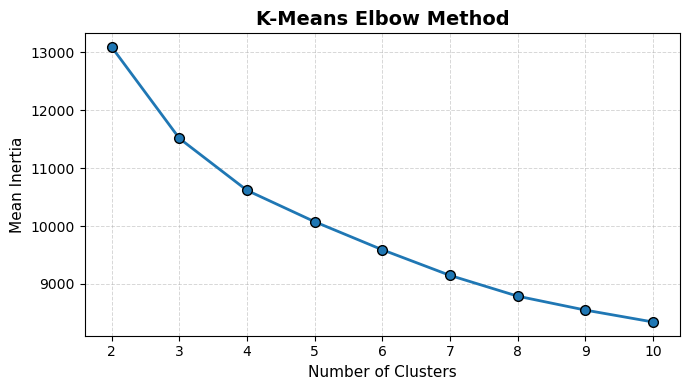

In [92]:
k_summary = (
    k_results.groupby("n_clusters").agg(mean_inertia=("inertia", "mean"),
                                        best_silhouette=("silhouette_score", "max")).reset_index())

# Elbow Method
plt.figure(figsize=(7, 4))

plt.plot(
    k_summary["n_clusters"],
    k_summary["mean_inertia"],
    marker="o",
    markersize=7,
    linewidth=2,
    markeredgecolor="black",
    markeredgewidth=1
)

plt.title(
    "K-Means Elbow Method",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters", fontsize=11)
plt.ylabel("Mean Inertia", fontsize=11)

plt.xticks(k_summary["n_clusters"], fontsize=10)
plt.yticks(fontsize=10)

plt.grid(
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

plt.tight_layout()
plt.show()

# Silhoutte Score
> The Silhouette Score measures how well customers fit into their own cluster and how separate they are from other clusters.

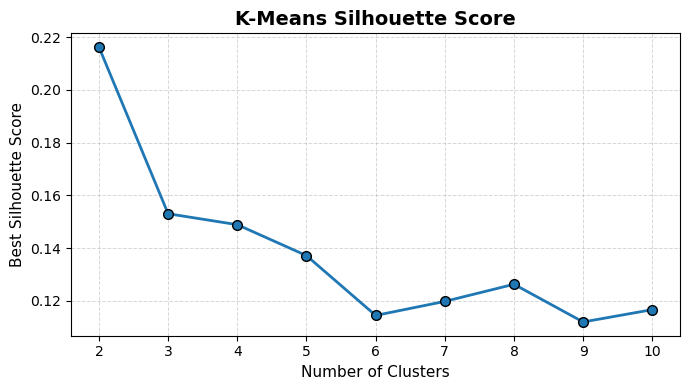

In [93]:
plt.figure(figsize=(7, 4))

plt.plot(
    k_summary["n_clusters"],
    k_summary["best_silhouette"],
    marker="o",
    markersize=7,
    linewidth=2,
    markeredgecolor="black",
    markeredgewidth=1
)

plt.title(
    "K-Means Silhouette Score",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Clusters", fontsize=11)
plt.ylabel("Best Silhouette Score", fontsize=11)

plt.xticks(k_summary["n_clusters"], fontsize=10)
plt.yticks(fontsize=10)

plt.grid(
    linestyle="--",
    linewidth=0.7,
    alpha=0.5
)

plt.tight_layout()
plt.show()

### Select the K-Means configuration

The configuration with the highest Silhouette Score is selected from the tuning results. In the final business workflow, K-Means is preferred because it creates a fixed number of customer segments and can easily assign a new customer to the nearest segment.

In [94]:
best_kmeans_params = (k_results.sort_values(["silhouette_score", "inertia"],ascending=[False, True]).iloc[0])

best_k = int(best_kmeans_params["n_clusters"])
best_n_init = int(best_kmeans_params["n_init"])
best_max_iter = int(best_kmeans_params["max_iter"])

kmeans_model = KMeans(n_clusters=best_k,
                      n_init=best_n_init,
                      max_iter=best_max_iter,
                      random_state=42)

kmeans_labels = kmeans_model.fit_predict(X_pca)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("Best K:", best_k)
print("Best n_init:", best_n_init)
print("Best max_iter:", best_max_iter)
print("Silhouette Score:", round(kmeans_silhouette, 4))

Best K: 2
Best n_init: 10
Best max_iter: 300
Silhouette Score: 0.21


## 12. DBSCAN Hyperparameter Tuning

DBSCAN is a density-based alternative. Unlike K-Means, it does not require a fixed number of clusters and can identify noise points.

However, a very high noise percentage is not useful for a practical customer-segmentation solution, so both clustering quality and noise level are considered.

In [95]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import (silhouette_score)

In [96]:
eps_values = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
min_samples_values = [5, 8, 10, 12, 15]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbmodel = DBSCAN(eps=eps,min_samples=min_samples)

        labels = dbmodel.fit_predict(X_pca)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        # clusters = Number of clusters found.
        
        n_noise = int(np.sum(labels == -1))
        # Number of Noise points found
        noise_ratio = n_noise / len(labels)
        
        mask = labels != -1
        # mask = Number of customers assigned to clusters.

### Suppose DBSCAN groups 100 customers into 2 clusters [100 > 2]
        if n_clusters >= 2 and mask.sum() > n_clusters:
            score = silhouette_score(X_pca[mask],labels[mask])
        else:
            score = np.nan
# X_pca[mask]  — selects only customers that belong to a cluster, excluding noise customers (-1).
# labels[mask] — selects the cluster labels for those same customers.

# Storing Values      
        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_ratio": noise_ratio,
            "silhouette_score": score,
        })

# Convert it into dataframe
dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results.sort_values("silhouette_score",ascending=False).head(10)

,eps,min_samples,n_clusters,n_noise,noise_ratio,silhouette_score
5,1.5,5,4,745,0.973856,0.521774
26,3.5,8,2,123,0.160784,0.306551
12,2.0,10,2,671,0.877124,0.296712
13,2.0,12,3,697,0.911111,0.275080
19,2.5,15,2,498,0.650980,0.218046
11,2.0,8,3,643,0.840523,0.154240
20,3.0,5,3,224,0.292810,0.131452
10,2.0,5,5,573,0.749020,0.118752
16,2.5,8,2,437,0.571242,0.112095
15,2.5,5,8,389,0.508497,0.029786


In [109]:
valid_dbscan = dbscan_results.dropna(subset=["silhouette_score"])
# dropna() removes rows with missing values in silhoutte score

if valid_dbscan.empty:
    raise ValueError(
        "No valid DBSCAN configuration produced at least two clusters. "
        "Try a wider eps range.")
# if DataFrame has zero rows, stops execution and displays an error message


practical_dbscan = valid_dbscan[valid_dbscan["noise_ratio"] <= 0.30]
# This selects configurations where the noise ratio is at most 0.30, or 30%.

# Select the best configuration
best_dbscan_params = (practical_dbscan.sort_values(["silhouette_score"],ascending=[False]).iloc[0])

# Extract the parameters
best_eps = float(best_dbscan_params["eps"])
best_min_samples = int(best_dbscan_params["min_samples"])

# Build DBSCAN Model
dbscan_model = DBSCAN(eps=best_eps,min_samples=best_min_samples)

# Train the model
dbscan_labels = dbscan_model.fit_predict(X_pca)

### Identify clustered customers and noise

dbscan_mask = dbscan_labels != -1
# dbscan_mask       = Number of customers assigned to clusters.

dbscan_clusters = len(np.unique(dbscan_labels[dbscan_mask]))
# dbscan_clusters   = Number of clusters found.
### dbscan_labels[dbscan_mask] : selects only customers assigned to clusters.
### np.unique()                : identifies the distinct cluster labels.
### len()                      : counts those labels.

dbscan_noise = int(np.sum(dbscan_labels == -1))
# Count noise points

dbscan_noise_ratio = dbscan_noise / len(dbscan_labels)
# Calculate the noise percentage

### Suppose DBSCAN groups 100 customers into 2 clusters [100 > 2]
if dbscan_clusters >= 2 and dbscan_mask.sum() > dbscan_clusters:
    dbscan_silhouette = silhouette_score(X_pca[dbscan_mask],dbscan_labels[dbscan_mask])
else:
    dbscan_silhouette = np.nan
# X_pca[dbscan_mask] — selects only customers that belong to a cluster, excluding noise customers (-1).
# dbscan_labels[dbscan_mask] — selects the cluster labels for those same customers.


# Displays    
print("Best EPS:", best_eps)
print("Best Min Samples:", best_min_samples)
print("Number of Clusters:", dbscan_clusters)
print("Noise Points:", dbscan_noise)
print("Noise Percentage:", round(dbscan_noise_ratio * 100, 2), "%")
print("Silhouette Score:", round(dbscan_silhouette, 4))

Best EPS: 3.5
Best Min Samples: 8
Number of Clusters: 2
Noise Points: 123
Noise Percentage: 16.08 %
Silhouette Score: 0.3052


## 13. Compare K-Means and DBSCAN

Both models are evaluated using the same standardized customer feature matrix. K-Means is especially useful for this business problem because it produces a fixed number of actionable segments and does not classify a large portion of customers as noise.

In [103]:
comparison = pd.DataFrame({
    "Model": ["K-Means", "DBSCAN"],
    "Silhouette Score": [kmeans_silhouette, dbscan_silhouette],
    "Number of Clusters": [best_k, dbscan_clusters],
    "Noise Percentage": [0.0, dbscan_noise_ratio * 100]
})

comparison.round(4)

,Model,Silhouette Score,Number of Clusters,Noise Percentage
0,K-Means,0.2100,2,0.0000
1,DBSCAN,0.3052,2,16.0784


In [104]:
if (
    pd.notna(dbscan_silhouette)
    and dbscan_silhouette > kmeans_silhouette
):

    FINAL_MODEL = dbscan_model
    FINAL_LABELS = dbscan_labels
    FINAL_MODEL_NAME = "DBSCAN"

    # Remove DBSCAN noise points for Silhouette calculation
    final_mask = FINAL_LABELS != -1

    FINAL_SILHOUETTE = silhouette_score(
        X_scaled.loc[final_mask],
        FINAL_LABELS[final_mask]
    )

else:

    FINAL_MODEL = kmeans_model
    FINAL_LABELS = kmeans_labels
    FINAL_MODEL_NAME = "K-Means"

    FINAL_SILHOUETTE = silhouette_score(X_scaled,FINAL_LABELS)

## CREATE FINAL CUSTOMER DATASET

In [105]:
# Use exactly the same rows used for clustering
final_data = data_clean.loc[X.index].copy()

# Add cluster labels
final_data["Customer_Segment"] = FINAL_LABELS

## Final Model Selection

In [106]:
print("Final Model:", FINAL_MODEL_NAME)
print("Silhouette Score:",round(FINAL_SILHOUETTE, 4))

if FINAL_MODEL_NAME == "DBSCAN":

    print("EPS:", best_eps)
    print("Min Samples:", best_min_samples)
    print("Number of Clusters:", dbscan_clusters)
    print("Noise Percentage:",round(dbscan_noise_ratio * 100, 2),"%")

else:

    print("Number of Clusters:", best_k)
    print("n_init:", best_n_init)
    print("max_iter:", best_max_iter)

print(
    "Customers used for clustering:",
    len(final_data)
)

Final Model: DBSCAN
Silhouette Score: 0.3066
EPS: 3.5
Min Samples: 8
Number of Clusters: 2
Noise Percentage: 16.08 %
Customers used for clustering: 765


# Save the model

In [119]:

from pickle import dump

with open("dbscan_model.pkl", "wb") as file:
    dump(dbscan_model, file)

print("DBSCAN model saved successfully!")


DBSCAN model saved successfully!


# Verify the Saved file is exist

In [120]:

import os

print("File exists:", os.path.exists("dbscan_model.pkl"))
print("File location:", os.path.abspath("dbscan_model.pkl"))


File exists: True
File location: C:\Users\ashwi\CUST SEG\dbscan_model.pkl


In [121]:

from pickle import load

with open("dbscan_model.pkl", "rb") as file:
    loaded_dbscan = load(file)

print("DBSCAN model loaded successfully!")
print("Model type:", type(loaded_dbscan).__name__)
print("EPS:", loaded_dbscan.eps)
print("Min samples:", loaded_dbscan.min_samples)


DBSCAN model loaded successfully!
Model type: DBSCAN
EPS: 3.5
Min samples: 8


In [122]:

import os
import joblib
import numpy as np

# Create the deployment folder
os.makedirs("deployment_artifacts", exist_ok=True)

# Preserve the exact training feature order
feature_columns = Y.columns.tolist()

# Preserve separate category mappings
education_categories = sorted(
    data_clean["Education"].dropna().unique().tolist()
)

marital_categories = sorted(
    data_clean["Marital_Status"].dropna().unique().tolist()
)

# Get the DBSCAN core samples
core_indices = dbscan_model.core_sample_indices_

core_points = X_pca[core_indices]
core_labels = dbscan_labels[core_indices]

# Save all required deployment objects
artifacts = {
    "model_name": "DBSCAN",
    "dbscan_model": dbscan_model,
    "scaler": scaler,
    "pca": pca,
    "feature_columns": feature_columns,
    "education_categories": education_categories,
    "marital_categories": marital_categories,
    "income_mean": float(data["Income"].mean()),
    "core_points": core_points,
    "core_labels": core_labels,
    "eps": dbscan_model.eps,
    "min_samples": dbscan_model.min_samples,
    "reference_year": 2026
}

artifact_path = os.path.join(
    "deployment_artifacts",
    "dbscan_bundle.joblib"
)

joblib.dump(artifacts, artifact_path)

print("Updated deployment bundle saved!")
print("Features:", len(feature_columns))
print("Education categories:", education_categories)
print("Marital categories:", marital_categories)
print("Core points:", core_points.shape)
print("Saved to:", os.path.abspath(artifact_path))


Updated deployment bundle saved!
Features: 32
Education categories: ['2n Cycle', 'Basic', 'Graduation', 'Master', 'PhD']
Marital categories: ['Alone', 'Divorced', 'Married', 'Single', 'Together', 'Widow']
Core points: (526, 14)
Saved to: C:\Users\ashwi\CUST SEG\deployment_artifacts\dbscan_bundle.joblib
